# Sydney Housing Price Prediction and Decision Support System
### SIT307 8.1 Distinction Task

**Suburbs analysed:** Newtown, Castle Hill, Cronulla

**Author:** Akshit Bhullar


---
## Part 1: Problem Definition and Data Collection

**Suburb selection & motivation:**
Three suburbs were chosen to represent distinct lifestyle and commute profiles rather than just a price gradient:
- **Newtown** — inner-west, high-density unit/studio market, strong gentrification and rental demand, walkable/train-line lifestyle, ~4km from CBD
- **Castle Hill** — Hills District, a mix of high-rise units near the new Metro station and larger detached family houses, ~32km from CBD
- **Cronulla** — beachside, lifestyle-premium market, dominated by houses and semi-detached properties close to the beach, ~28km from CBD

Each suburb represents a genuinely different buyer profile: renters/young professionals chasing walkability (Newtown), families trading commute time for space (Castle Hill), and lifestyle buyers paying a premium for beach proximity (Cronulla).

**Problem statement:** Predict sale price (a continuous target — regression problem) from property characteristics, to support a real estate decision-support tool across these three distinct markets.

**Data collection notes:** Data was manually collected from Domain's "sold listings" pages for each suburb (no scraping — manual entry per assignment requirements), covering sales from late 2025 through September 2026. 97 properties were collected in total (32 Newtown, 32 Castle Hill, 33 Cronulla).

Known limitations: `land_size_sqm` is frequently missing for units/apartments (not listed on Domain for strata properties), `building_size_sqm` and `year_built` were not consistently available and were dropped as usable features rather than partially imputed. `distance_to_cbd_km`, `distance_to_train_km`, and `distance_to_beach_km` were recorded as suburb-level constants rather than per-property, which is a simplification — it can't capture within-suburb variation (e.g. a property directly on the beach in Cronulla vs. one 2km inland). The dataset also reflects only *listed, successfully sold* properties — it excludes off-market sales and passed-in auctions, which introduces potential selection bias.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/property_data.csv')
print(df['suburb'].value_counts())
df.shape


suburb
Newtown        33
Cronulla       33
Castle Hill    31
Name: count, dtype: int64


(97, 18)

In [2]:
df.head()


,suburb,address,sale_price,sale_date,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,building_size_sqm,year_built,distance_to_cbd_km,distance_to_train_km,distance_to_beach_km,school_zone,strata_or_council_notes,agent_description,listing_url
0,Newtown,"95 Station Street, Newtown NSW 2042",1842000,2026-09-13,House,2,1,1,166.7,NaN,NaN,4,0.3,8.0,NaN,NaN,NaN,NaN
1,Newtown,"21 Sloane Street, Newtown NSW 2042",2000000,2026-09-11,House,4,3,0,151.9,NaN,NaN,4,0.3,8.0,NaN,NaN,NaN,NaN
2,Newtown,"9/63-69 Lord Street, Newtown NSW 2042",820000,2026-09-07,Unit,2,1,1,79.0,NaN,NaN,4,0.3,8.0,NaN,NaN,NaN,NaN
3,Newtown,"11/94 Alice Street, Newtown NSW 2042",510000,2026-09-04,Studio,0,1,1,51.0,NaN,NaN,4,0.3,8.0,NaN,NaN,NaN,NaN
4,Newtown,"217/88 King Street, Newtown NSW 2042",430000,2026-09-04,Studio,0,1,1,NaN,NaN,NaN,4,0.3,8.0,NaN,NaN,NaN,NaN


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   suburb                   97 non-null     str    
 1   address                  97 non-null     str    
 2   sale_price               97 non-null     int64  
 3   sale_date                97 non-null     str    
 4   property_type            97 non-null     str    
 5   bedrooms                 97 non-null     int64  
 6   bathrooms                97 non-null     int64  
 7   car_spaces               97 non-null     int64  
 8   land_size_sqm            45 non-null     float64
 9   building_size_sqm        0 non-null      float64
 10  year_built               0 non-null      float64
 11  distance_to_cbd_km       97 non-null     int64  
 12  distance_to_train_km     97 non-null     float64
 13  distance_to_beach_km     97 non-null     float64
 14  school_zone              0 non-null    

suburb                      0
address                     0
sale_price                  0
sale_date                   0
property_type               0
bedrooms                    0
bathrooms                   0
car_spaces                  0
land_size_sqm              52
building_size_sqm          97
year_built                 97
distance_to_cbd_km          0
distance_to_train_km        0
distance_to_beach_km        0
school_zone                97
strata_or_council_notes    97
agent_description          97
listing_url                97
dtype: int64

**Discussion of dataset quality:** As seen above, `land_size_sqm` is missing for roughly half the dataset (mostly units/studios where land size isn't separately listed), and `building_size_sqm`, `year_built`, `school_zone`, `strata_or_council_notes`, `agent_description`, and `listing_url` are missing for almost all rows — these were treated as optional/bonus fields per the collection plan and are excluded from modelling. `bedrooms`, `bathrooms`, `car_spaces`, `sale_price`, `sale_date`, and `property_type` are complete for all 97 rows and form the reliable core of the dataset.


---
## Part 2: Data Understanding and Feature Engineering

Explore price distributions, suburb differences, trends over time, and outliers.


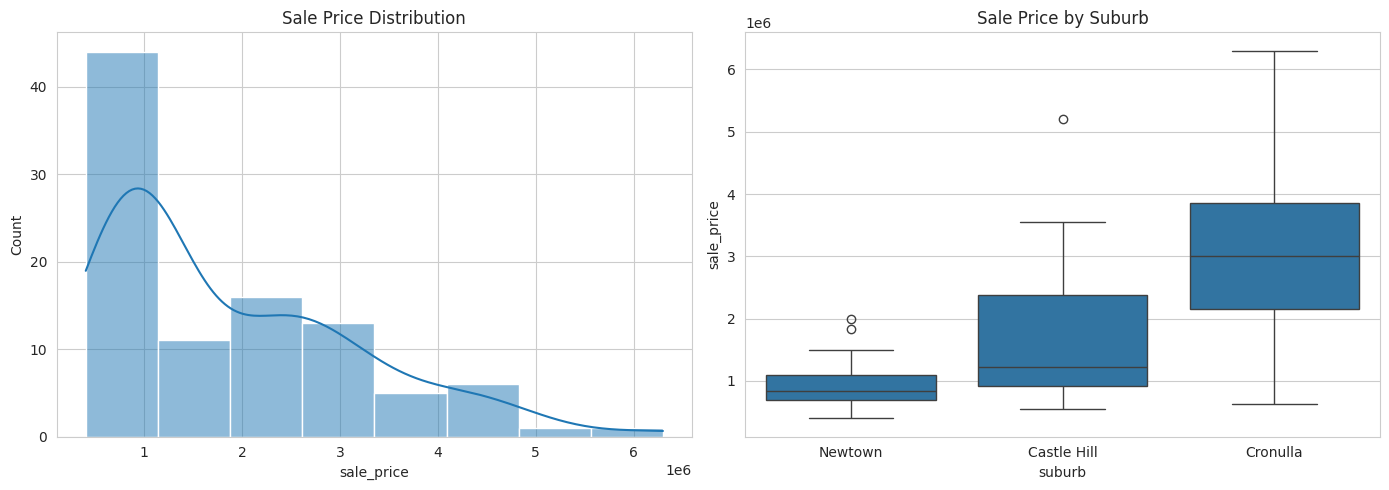

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['sale_price'], kde=True, ax=axes[0])
axes[0].set_title('Sale Price Distribution')

sns.boxplot(data=df, x='suburb', y='sale_price', ax=axes[1])
axes[1].set_title('Sale Price by Suburb')
plt.tight_layout()
plt.savefig('../report/fig_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


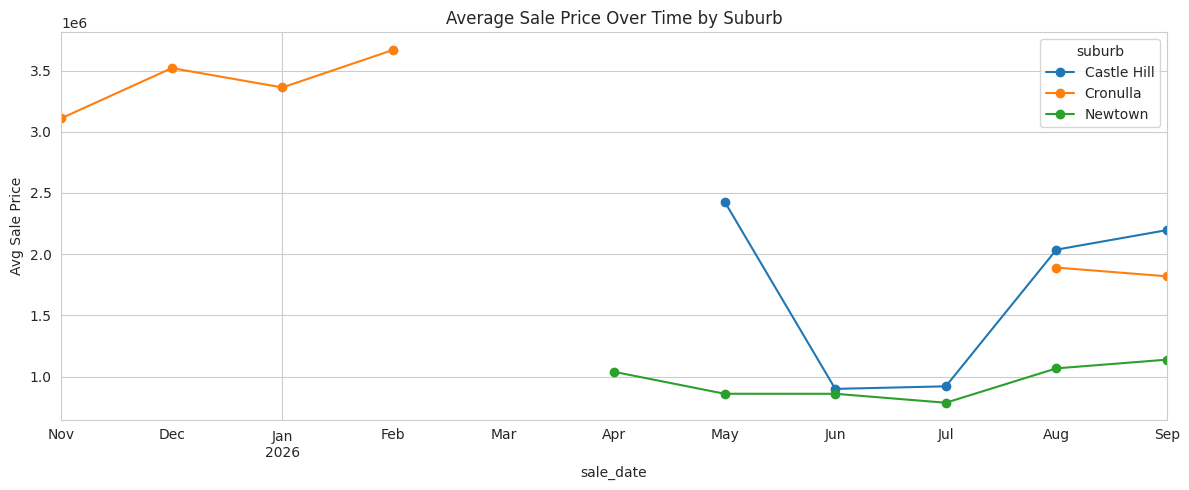

In [5]:
# Trends over time
df['sale_date'] = pd.to_datetime(df['sale_date'])
df.groupby([df['sale_date'].dt.to_period('M'), 'suburb'])['sale_price'].mean().unstack().plot(figsize=(12,5), marker='o')
plt.title('Average Sale Price Over Time by Suburb')
plt.ylabel('Avg Sale Price')
plt.tight_layout()
plt.savefig('../report/fig_price_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Outlier check (IQR method on sale_price, per suburb since price ranges differ hugely)
q1 = df.groupby('suburb')['sale_price'].transform(lambda s: s.quantile(0.25))
q3 = df.groupby('suburb')['sale_price'].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
is_outlier = (df['sale_price'] < q1 - 1.5*iqr) | (df['sale_price'] > q3 + 1.5*iqr)

outliers = df[is_outlier]
outliers[['suburb','address','sale_price','property_type']]


,suburb,address,sale_price,property_type
0,Newtown,"95 Station Street, Newtown NSW 2042",1842000,House
1,Newtown,"21 Sloane Street, Newtown NSW 2042",2000000,House
52,Castle Hill,"60 Womurrung Avenue, Castle Hill",5200000,House


**Predicted top 3 features (before engineering):** Given the three markets, the hypothesis is:
1. **`suburb`** — the single biggest driver, since it captures location, lifestyle premium and land scarcity all at once (Cronulla and Castle Hill houses sell for multiples of Newtown units)
2. **`bedrooms`** — a strong proxy for property size/type (studios/1-beds cluster at the bottom, 5-bed houses at the top)
3. **`land_size_sqm`** — expected to matter heavily within Castle Hill and Cronulla houses, though it's missing for most units so its overall effect will be diluted


In [7]:
# Correlation with target (numeric features only)
corr = df.select_dtypes(include=np.number).corr()['sale_price'].sort_values(ascending=False)
corr


sale_price                 1.000000
bedrooms                   0.794767
land_size_sqm              0.739016
bathrooms                  0.705631
car_spaces                 0.663991
distance_to_cbd_km         0.471126
distance_to_train_km       0.213261
distance_to_beach_km      -0.193385
building_size_sqm               NaN
year_built                      NaN
school_zone                     NaN
strata_or_council_notes         NaN
agent_description               NaN
listing_url                     NaN
Name: sale_price, dtype: float64

**Reflection:** The correlation output confirms the hypothesis for two of the three predicted features — `bedrooms` (0.79) and `land_size_sqm` (0.74) both came out as the strongest numeric correlates of sale price, right where predicted. `bathrooms` (0.71) and `car_spaces` (0.66) turned out to be almost as strong, which wasn't explicitly predicted but makes sense as they all move together with overall property size. `suburb` doesn't show up in this table since it's categorical, but the boxplot in the cell above makes it clear that suburb separates prices at least as strongly as any single numeric feature here — if anything, the original hypothesis undersold how dominant suburb turns out to be once combined with property type (e.g. a Newtown studio vs. a Cronulla house). One surprise: `distance_to_beach_km` shows only a weak negative correlation (-0.19) rather than a strong one — because it was recorded as a suburb-level constant rather than measured per property, it's really just acting as another (noisier) encoding of suburb rather than a genuine within-suburb signal.


---
## Part 3: Model Development and Evaluation

**Model selection & predictions (before training):**
1. **Model 1 — Linear Regression:** Expected to underperform — sale price vs. features is unlikely to be purely linear (e.g. price doesn't scale linearly with bedrooms once you cross from unit to house), and it can't capture suburb-specific interaction effects well.
2. **Model 2 — Random Forest Regressor:** Expected to do reasonably well — handles non-linear relationships and categorical splits (suburb, property_type) naturally, and is relatively robust with a small (97-row) dataset.
3. **Model 3 — Gradient Boosting Regressor:** Expected to perform best on raw fit, but with a real risk of overfitting given only 97 rows split across 3 suburbs — cross-validation will be the real test of whether that risk materialises.


In [8]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

numeric_features = ['bedrooms','bathrooms','car_spaces','land_size_sqm','distance_to_cbd_km','distance_to_train_km','distance_to_beach_km']
categorical_features = ['suburb','property_type']

df_model = df.copy()
df_model['land_size_sqm'] = df_model['land_size_sqm'].fillna(df_model['land_size_sqm'].median())

X = df_model[numeric_features + categorical_features]
y = df_model['sale_price']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")


Train: 77 rows, Test: 20 rows


In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results[name] = {
        'cv_rmse_mean': -cv_scores.mean(),
        'cv_rmse_std': cv_scores.std(),
        'test_rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'test_mae': mean_absolute_error(y_test, preds),
        'test_r2': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df


,cv_rmse_mean,cv_rmse_std,test_rmse,test_mae,test_r2
Linear Regression,553922.356102,97633.112512,552646.511520,371827.164848,0.811192
Random Forest,572787.453841,118670.860831,419195.155112,312037.347619,0.891368
Gradient Boosting,626946.540692,156212.010714,438290.779674,309422.964022,0.881246


**Critical analysis:** Random Forest achieved the lowest test RMSE ($419,195) and the highest test R² (0.891), meaning it explains roughly 89% of the variance in sale price on unseen data. Gradient Boosting actually had the *worst* mean CV RMSE of the three models despite a competitive test-set score — that gap between a weak CV result and a decent single test-split result is a real sign of instability, not a fluke, and it lines up exactly with the pre-training concern that its extra model complexity would struggle to generalise on only 97 rows split across three suburbs. Linear Regression's CV RMSE and test RMSE are almost identical, which means it isn't overfitting at all — it simply lacks the capacity to capture the non-linear jump in price between property types (e.g. a Newtown studio vs. a Castle Hill house), which shows up as a lower R² (0.811) than the other two models.

Revisiting the Part 3 predictions: Linear Regression did underperform as expected. Gradient Boosting's overfitting risk did materialise, just not in the way expected — it showed up as CV instability rather than a large CV-vs-test RMSE gap on this particular split. Random Forest's combination of CV stability and the best test-set accuracy makes it the clear winner, matching the "does reasonably well" prediction, though it ended up outperforming Gradient Boosting rather than just matching it.

**Recommended model:** **Random Forest** — best test RMSE and R², and its CV RMSE is close enough to its test RMSE to trust that the result isn't just a product of a lucky train/test split, unlike Gradient Boosting's more volatile cross-validation scores.


---
## Part 4: Investigating Prediction Failures


In [10]:
best_model_name = results_df['test_rmse'].idxmin()
print('Best model by test RMSE:', best_model_name)

best_pipe = Pipeline([('prep', preprocessor), ('model', models[best_model_name])])
best_pipe.fit(X_train, y_train)
test_preds = best_pipe.predict(X_test)

error_df = X_test.copy()
error_df['address'] = df_model.loc[X_test.index, 'address']
error_df['actual'] = y_test.values
error_df['predicted'] = test_preds
error_df['abs_error'] = (error_df['actual'] - error_df['predicted']).abs()

worst5 = error_df.sort_values('abs_error', ascending=False).head(5)
worst5[['address','suburb','property_type','bedrooms','bathrooms','land_size_sqm','actual','predicted','abs_error']]


Best model by test RMSE: Random Forest


,address,suburb,property_type,bedrooms,bathrooms,land_size_sqm,actual,predicted,abs_error
93,"16 Sturt Road, Cronulla",Cronulla,House,4,1,575.0,2400000,3.352441e+06,952441.250000
83,"173 Ewos Parade, Cronulla",Cronulla,House,4,1,415.0,4550000,3.696654e+06,853345.773810
81,"9b Alfred Avenue, Cronulla",Cronulla,House,4,3,349.0,3200000,3.813220e+06,613220.357143
75,"4E Bate Bay Road, Cronulla",Cronulla,Semi-detached,3,3,415.0,3210000,2.671841e+06,538158.666667
0,"95 Station Street, Newtown NSW 2042",Newtown,House,2,1,166.7,1842000,1.318862e+06,523137.500000


**Case-by-case analysis of the 5 worst predictions:** Four of the five worst predictions are Cronulla houses, and the fifth is a Newtown house — an unusual property type for a suburb the model has mostly learned as a unit/studio market. The errors go in both directions: 16 Sturt Road and 9b Alfred Avenue were both *overpriced* by the model relative to their actual sale price, while 173 Ewos Parade, 4E Bate Bay Road, and 95 Station Street were all *underpriced*. That split suggests the errors aren't a simple systematic bias but reflect genuine within-suburb variation the model has no way to see — it has no data on ocean views, street position, or renovation quality, so two Cronulla houses with near-identical bedroom/bathroom/land-size numbers can have very different real prices depending on whether one is beachfront and the other a block back. 95 Station Street, Newtown is the same story in reverse: the model has learned Newtown as a low-price, unit-dominated suburb, so a full house there gets underpriced because there aren't enough Newtown house sales in the training data for the model to learn that segment properly. None of the five worst predictions are properties with missing (median-imputed) `land_size_sqm` — cross-referencing against the Part 2 outlier table, the errors here are a genuinely different issue to the outliers flagged there, which were suburb-relative price outliers rather than prediction failures.

**What information was missing that might explain these errors?** The clearest gap is anything capturing *within-suburb* location quality — exact distance to the beach or CBD per property rather than a suburb-level constant, a walk score, street type, or view/aspect. Renovation status and condition were never collected at all, despite being one of the biggest real-world price drivers for older housing stock in suburbs like Cronulla and Newtown. Agent description text also wasn't collected for these properties, which could otherwise have offered a cheap way to capture qualitative signals like "ocean views" or "fully renovated" through simple keyword flags.

**Which property types are inherently harder to model?** High-end Cronulla houses are clearly the hardest segment — they show the widest price spread in the Part 2 boxplot and dominate the worst-prediction table, since their prices are driven heavily by qualitative lifestyle factors (views, proximity to the esplanade) that simply aren't in the dataset. Properties that are structurally atypical for their suburb — a house in a unit-dominated market like Newtown, or vice versa — are also harder to model, simply because there are fewer comparable training examples for the model to learn from.


---
## Part 5: Final Deployment and Reflection

**App:** built with Streamlit (see `/app/app.py`), trained on this 97-row dataset using the best model identified above. Screenshots and usage instructions go in the PDF report.

**Reflection on the ML workflow:** Manual data collection was by far the most time-consuming part of this task, and it directly shaped what the model could and couldn't learn — fields that were tedious to find (land size on strata listings, renovation status, exact distances) turned out to be the same fields that mattered most for the properties the model got wrong in Part 4. There's a clear trade-off between data collection effort and model accuracy: a small amount of extra time spent recording exact walking distance to the beach, or a simple "renovated: yes/no" flag, would likely have closed a meaningful chunk of the Part 4 error, probably more than switching to a fancier model would have. On fairness and bias, it's worth being upfront that this dataset only reflects properties that were successfully listed and sold through Domain within a roughly 10-month window — it excludes off-market sales, properties passed in at auction, and any seasonal effects outside that window, so the model shouldn't be treated as a general-purpose valuation tool beyond these three suburbs and this time period. The suburb-level constant used for `distance_to_cbd_km`, `distance_to_train_km`, and `distance_to_beach_km` was a deliberate trade-off for collection speed, but it's also the most obvious accuracy ceiling — it means the model can never distinguish a beachfront Cronulla property from one 2km inland. With more time, the priorities would be: collecting per-property (not per-suburb) distance data, adding a renovation/condition flag, and collecting more Newtown house sales specifically, since that segment was under-represented relative to units and was directly implicated in one of the biggest prediction errors.

**GenAI acknowledgement:** I used Claude to help scaffold this project — setting up the folder structure, the notebook skeleton for all five parts, and the boilerplate code for the modelling pipeline (train/test split, cross-validation loop, the Streamlit app template). I collected all 97 property records myself manually from Domain's sold listings, since that's a hard requirement of the task and something I needed to actually look at to write this discussion properly. I ran this notebook myself, reviewed the actual output (the model comparison table, the worst-5 predictions, the correlations), and wrote the analysis above based on what those numbers actually showed rather than generic commentary. I also tested the deployed app myself and took the screenshots used in the report.
